In [1]:
%cd /iridisfs/home/lhl1g23/ssm/mamba
import warnings
warnings.filterwarnings('ignore')
from models.dataloaders.dataloaders import get_sc
from analyse.utils.plots import plot_eigen, plot_frequency_repsponse_one_step, plot_z_transform_one_step
from train.train import MambaClassifierTrainer
from omegaconf import OmegaConf
import torch
import numpy as np
import matplotlib.pyplot as plt

train, val, test = get_sc()
train_iter, val_iter, test_iter = iter(train), iter(val), iter(test)

/iridisfs/home/lhl1g23/ssm/mamba


CUDA extension for structured kernels (Cauchy and Vandermonde multiplication) not found. Install by going to extensions/kernels/ and running `python setup.py install`, for improved speed and memory efficiency. Note that the kernel changed for state-spaces 4.0 and must be recompiled.
Falling back on slow Cauchy and Vandermonde kernel. Install at least one of pykeops or the CUDA extension for better speed and memory efficiency.


In [2]:
X, y = next(test_iter)
X, y = X.to('cuda'),y.to('cuda')

In [3]:
config = OmegaConf.load('models/configs/sc/sc_raw_complex_circle.yaml')

model = MambaClassifierTrainer.load_from_checkpoint(
    '/scratch/lhl1g23/checkpoints/sc/raw/complex/circle_fix/best-v19.ckpt',
    data="sc",
    mamba_config=config.mamba,
    model_config=config.model
).to('cuda')

model.eval()
torch.set_grad_enabled(False)

params = next(model.classifier.get_params(X[:1]))

A = params['A']
B = params['B']
C = params['C']
D = params['D']
dA = params['dA']
dB = params['dB']
dt = params['dt']
states = params['states']
y_ssm = params['y_ssm']

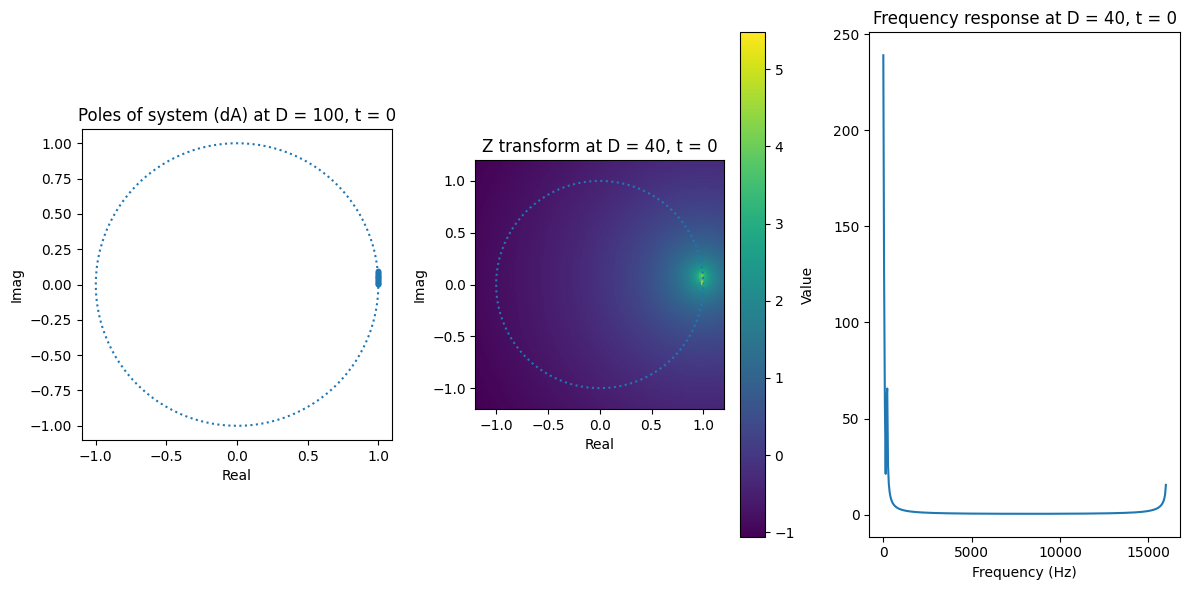

In [ ]:
sample, d, t = 0, 40, 0

fig, ax = plt.subplots(1, 3, figsize=(12,6))
plot_eigen(dA[sample, t, d, :], ax[0], s=10, title=f"Poles of system (dA) at D = {d}, t = {t}")
plot_z_transform_one_step(dA, dB, C, sample, d, t, ax=ax[1], log=True)
plot_frequency_repsponse_one_step(dA, dB, C, sample, d, t, ax[2])
plt.tight_layout()
plt.show()

In [6]:
model_untrained = MambaClassifierTrainer(
    data="sc",
    mamba_config=config.mamba,
    model_config=config.model
).to('cuda')

model.eval()
torch.set_grad_enabled(False)

params = next(model_untrained.classifier.get_params(X[:1]))

A_untrained = params['A']
dA_untrained = params['dA']

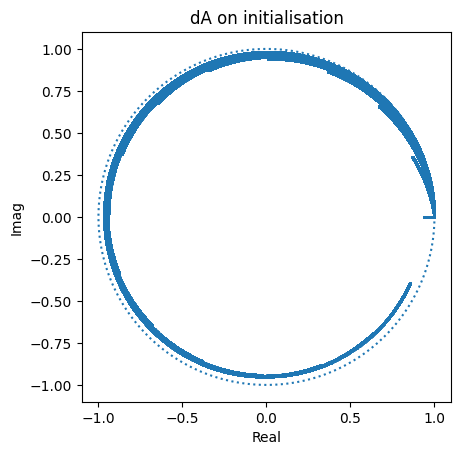

In [7]:
plot_eigen(dA_untrained[0,:,:,:].flatten(start_dim=2), title="dA on initialisation", ax=plt.gca())